In [1]:
import torch

if torch.cuda.is_available():
    print("GPU is available!")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("GPU is not available. Isaac Gym requires an NVIDIA GPU.")

GPU is available!
GPU Name: Tesla T4


In [2]:
!nvidia-smi

Thu Feb 19 11:26:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install numpy
!pip install imageio
!pip install matplotlib

In [4]:
!tar -xvf IsaacGym_Preview_4_Package.tar.gz

tar: IsaacGym_Preview_4_Package.tar.gz: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now


In [5]:
%cd isaacgym/python

[Errno 2] No such file or directory: 'isaacgym/python'
/content


In [6]:
!pip install -e .

Obtaining file:///content
ERROR: file:///content does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [7]:
!pip install warp-lang

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 MB 6.0 MB/s eta 0:00:00


In [8]:
import warp as wp

wp.init()

print("Available devices:", wp.get_devices())
print("Current device:", wp.get_device())

Warp 1.11.1 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "Tesla T4" (15 GiB, sm_75, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.11.1
Available devices: ['cpu', 'cuda:0']
Current device: cuda:0


In [9]:
import warp as wp
import numpy as np

wp.init()

# Simulation parameters
dt = 0.01
gravity = -9.81
restitution = 0.8
radius = 0.1
steps = 500

# Allocate GPU arrays
position = wp.array([1.0], dtype=float, device="cuda")
velocity = wp.array([0.0], dtype=float, device="cuda")

@wp.kernel
def simulate(pos: wp.array(dtype=float),
             vel: wp.array(dtype=float),
             g: float,
             dt: float,
             r: float,
             rest: float):

    i = wp.tid()

    # Apply gravity
    vel[i] = vel[i] + g * dt

    # Update position
    pos[i] = pos[i] + vel[i] * dt

    # Collision with ground
    if pos[i] < r:
        pos[i] = r
        vel[i] = -vel[i] * rest

# Run simulation
positions_over_time = []

for s in range(steps):
    wp.launch(simulate,
              dim=1,
              inputs=[position, velocity, gravity, dt, radius, restitution],
              device="cuda")

    positions_over_time.append(position.numpy()[0])

print("Simulation finished.")

Module __main__ 4cca753 load on device 'cuda:0' took 1046.41 ms  (compiled)
Simulation finished.


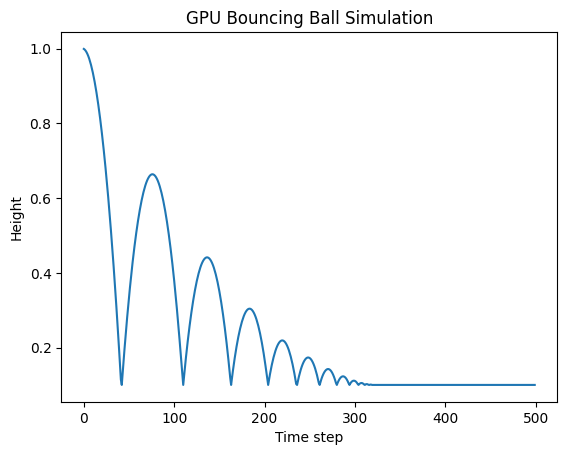

In [10]:
import matplotlib.pyplot as plt

plt.plot(positions_over_time)
plt.title("GPU Bouncing Ball Simulation")
plt.xlabel("Time step")
plt.ylabel("Height")
plt.show()

Module __main__ f73d3aa load on device 'cuda:0' took 394.54 ms  (compiled)
Parallel simulation complete.
Average final height: 0.10000002


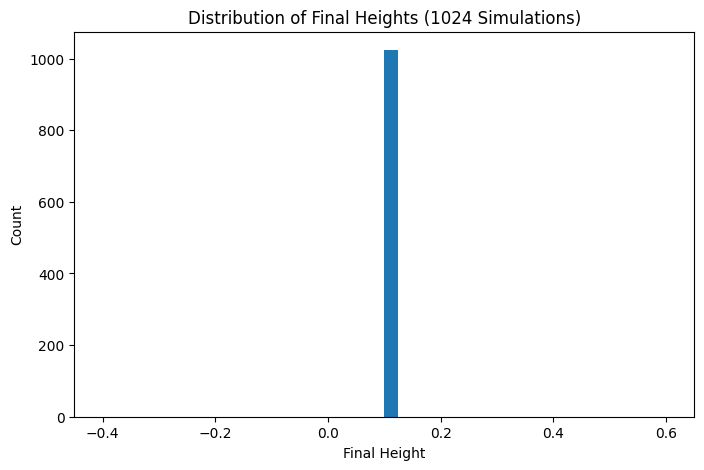

In [11]:
import warp as wp
import numpy as np
import matplotlib.pyplot as plt

wp.init()

# Simulation Parameters
dt = 0.01
gravity = -9.81
restitution = 0.8
radius = 0.1
steps = 500
num_envs = 1024

# Allocate GPU Arrays
initial_heights = np.random.uniform(0.5, 2.0, num_envs)

position = wp.array(initial_heights, dtype=float, device="cuda")
velocity = wp.zeros(num_envs, dtype=float, device="cuda")


# Kernel
@wp.kernel
def simulate(pos: wp.array(dtype=float),
             vel: wp.array(dtype=float),
             g: float,
             dt: float,
             r: float,
             rest: float):

    i = wp.tid()

    vel[i] = vel[i] + g * dt
    pos[i] = pos[i] + vel[i] * dt

    if pos[i] < r:
        pos[i] = r
        vel[i] = -vel[i] * rest

# Run Simulation
for s in range(steps):
    wp.launch(simulate,
              dim=num_envs,
              inputs=[position, velocity, gravity, dt, radius, restitution],
              device="cuda")

final_heights = position.numpy()

print("Parallel simulation complete.")
print("Average final height:", np.mean(final_heights))

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(final_heights, bins=40)
plt.title("Distribution of Final Heights (1024 Simulations)")
plt.xlabel("Final Height")
plt.ylabel("Count")
plt.show()

In [12]:
import warp as wp
import numpy as np
import pandas as pd

wp.init()

# Parameters
dt = 0.01
gravity = -9.81
restitution = 0.8
radius = 0.1
steps = 500
num_envs = 1024

# Initial Conditions
initial_heights = np.random.uniform(0.5, 2.0, num_envs)

position = wp.array(initial_heights, dtype=float, device="cuda")
velocity = wp.zeros(num_envs, dtype=float, device="cuda")
bounce_count = wp.zeros(num_envs, dtype=int, device="cuda")

# Kernel
@wp.kernel
def simulate(pos: wp.array(dtype=float),
             vel: wp.array(dtype=float),
             bounce: wp.array(dtype=int),
             g: float,
             dt: float,
             r: float,
             rest: float):

    i = wp.tid()

    vel[i] = vel[i] + g * dt
    pos[i] = pos[i] + vel[i] * dt

    if pos[i] < r:
        pos[i] = r
        vel[i] = -vel[i] * rest
        bounce[i] = bounce[i] + 1


# Data Storage
trajectory_data = []

# Simulation Loop
for step in range(steps):

    wp.launch(simulate,
              dim=num_envs,
              inputs=[position, velocity, bounce_count,
                      gravity, dt, radius, restitution],
              device="cuda")

    pos_cpu = position.numpy()
    vel_cpu = velocity.numpy()
    bounce_cpu = bounce_count.numpy()

    for env in range(num_envs):
        trajectory_data.append([
            step,
            env,
            pos_cpu[env],
            vel_cpu[env],
            bounce_cpu[env]
        ])

print("Simulation complete.")

Module __main__ 775e97b load on device 'cuda:0' took 355.98 ms  (compiled)
Simulation complete.


In [13]:
df = pd.DataFrame(
    trajectory_data,
    columns=["step", "env_id", "position", "velocity", "bounce_count"]
)

print(df.head())
print("Total rows:", len(df))

   step  env_id  position  velocity  bounce_count
0     0       0  0.933522   -0.0981             0
1     0       1  1.386525   -0.0981             0
2     0       2  1.036521   -0.0981             0
3     0       3  0.724676   -0.0981             0
4     0       4  1.175357   -0.0981             0
Total rows: 512000


In [14]:
df.to_csv("warp_bouncing_ball_dataset.csv", index=False)
print("Dataset saved.")

Dataset saved.


In [15]:
import warp as wp
import numpy as np
import matplotlib.pyplot as plt

wp.init()

print("Device:", wp.get_device())

Device: cuda:0


In [16]:
import warp as wp
import numpy as np

wp.init()

# Parameters
dt = 0.01
steps = 500
num_envs = 256
balls_per_env = 4

gravity = -9.81
radius = 0.05
restitution = 0.9

total_balls = num_envs * balls_per_env

# Initial Conditions
pos_np = np.random.uniform(0.2, 0.8, (total_balls, 2))
vel_np = np.random.uniform(-1.0, 1.0, (total_balls, 2))

position = wp.array(pos_np, dtype=wp.vec2, device="cuda")
velocity = wp.array(vel_np, dtype=wp.vec2, device="cuda")

# Physics Kernel
@wp.kernel
def simulate(pos: wp.array(dtype=wp.vec2),
             vel: wp.array(dtype=wp.vec2),
             dt: float,
             g: float,
             r: float,
             rest: float):

    i = wp.tid()

    # Gravity (y only)
    vel[i][1] = vel[i][1] + g * dt

    # Update position
    pos[i] = pos[i] + vel[i] * dt

    # Floor
    if pos[i][1] < r:
        pos[i][1] = r
        vel[i][1] = -vel[i][1] * rest

    # Ceiling
    if pos[i][1] > 1.0 - r:
        pos[i][1] = 1.0 - r
        vel[i][1] = -vel[i][1] * rest

    # Left wall
    if pos[i][0] < r:
        pos[i][0] = r
        vel[i][0] = -vel[i][0] * rest

    # Right wall
    if pos[i][0] > 1.0 - r:
        pos[i][0] = 1.0 - r
        vel[i][0] = -vel[i][0] * rest


# Run Simulation
for s in range(steps):
    wp.launch(simulate,
              dim=total_balls,
              inputs=[position, velocity,
                      dt, gravity,
                      radius, restitution],
              device="cuda")

print("2D multi-ball simulation complete.")

Module __main__ 66fed9e load on device 'cuda:0' took 1389.22 ms  (compiled)
2D multi-ball simulation complete.


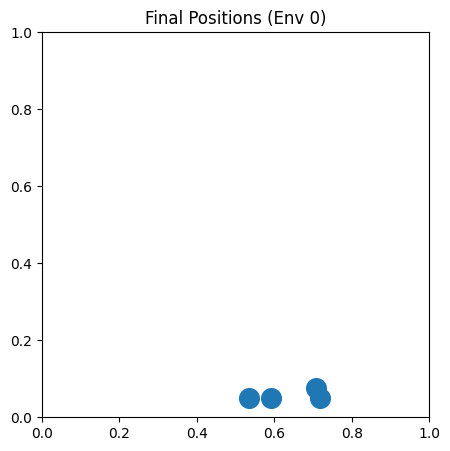

In [17]:
pos_cpu = position.numpy()

# Extract first environment balls
env0 = pos_cpu[:balls_per_env]

plt.figure(figsize=(5,5))
plt.scatter(env0[:,0], env0[:,1], s=200)
plt.xlim(0,1)
plt.ylim(0,1)
plt.title("Final Positions (Env 0)")
plt.show()

In [18]:
import warp as wp
import numpy as np
import os
import cv2
import pandas as pd

wp.init()

# Parameters
dt = 0.01
steps = 200
num_envs = 10          #  small for testing
balls_per_env = 4
gravity = -9.81
radius = 0.05
restitution = 0.9

image_size = 64
total_balls = num_envs * balls_per_env

# Create Output Folder
os.makedirs("dataset/images", exist_ok=True)

# Initialize State
pos_np = np.random.uniform(0.2, 0.8, (total_balls, 2))
vel_np = np.random.uniform(-1.0, 1.0, (total_balls, 2))

position = wp.array(pos_np, dtype=wp.vec2, device="cuda")
velocity = wp.array(vel_np, dtype=wp.vec2, device="cuda")

# Physics Kernel
@wp.kernel
def simulate(pos: wp.array(dtype=wp.vec2),
             vel: wp.array(dtype=wp.vec2),
             dt: float,
             g: float,
             r: float,
             rest: float):

    i = wp.tid()

    vel[i][1] = vel[i][1] + g * dt
    pos[i] = pos[i] + vel[i] * dt

    # Boundaries
    if pos[i][1] < r:
        pos[i][1] = r
        vel[i][1] = -vel[i][1] * rest

    if pos[i][1] > 1.0 - r:
        pos[i][1] = 1.0 - r
        vel[i][1] = -vel[i][1] * rest

    if pos[i][0] < r:
        pos[i][0] = r
        vel[i][0] = -vel[i][0] * rest

    if pos[i][0] > 1.0 - r:
        pos[i][0] = 1.0 - r
        vel[i][0] = -vel[i][0] * rest

print("Setup complete.")

Setup complete.


In [19]:
labels = []

for step in range(steps):

    #  Physics Step
    wp.launch(simulate,
              dim=total_balls,
              inputs=[position, velocity,
                      dt, gravity,
                      radius, restitution],
              device="cuda")

    pos_cpu = position.numpy()
    vel_cpu = velocity.numpy()

    #  For Each Environment
    for env in range(num_envs):

        img = np.zeros((image_size, image_size, 3), dtype=np.uint8)

        for b in range(balls_per_env):

            idx = env * balls_per_env + b
            x, y = pos_cpu[idx]

            # Convert to pixel space
            px = int(x * image_size)
            py = int((1 - y) * image_size)

            rad_pix = int(radius * image_size)

            # Draw circle
            cv2.circle(img, (px, py), rad_pix, (0,255,0), -1)

            # Bounding box
            x_min = px - rad_pix
            y_min = py - rad_pix
            x_max = px + rad_pix
            y_max = py + rad_pix

            labels.append([
                step,
                env,
                b,
                x, y,
                vel_cpu[idx][0],
                vel_cpu[idx][1],
                x_min, y_min,
                x_max, y_max
            ])

        # Save image
        filename = f"dataset/images/env{env}_step{step}.png"
        cv2.imwrite(filename, img)

print("Dataset generation complete.")

Module __main__ 4f764b7 load on device 'cuda:0' took 1344.40 ms  (compiled)
Dataset generation complete.


In [20]:
df = pd.DataFrame(labels, columns=[
    "step",
    "env_id",
    "object_id",
    "x",
    "y",
    "vx",
    "vy",
    "x_min",
    "y_min",
    "x_max",
    "y_max"
])

df.to_csv("dataset/labels.csv", index=False)

print("Label file saved.")
print("Total images:", steps * num_envs)
print("Total object annotations:", len(df))

Label file saved.
Total images: 2000
Total object annotations: 8000


In [21]:
import warp as wp
import numpy as np
import os
import cv2
import pandas as pd

wp.init()

dt = 0.01
steps = 200
num_envs = 10
balls_per_env = 4

image_size = 64
radius = 0.05

total_balls = num_envs * balls_per_env

os.makedirs("dataset_v2/images", exist_ok=True)
os.makedirs("dataset_v2/masks", exist_ok=True)

pos_np = np.random.uniform(0.2, 0.8, (total_balls, 2))
vel_np = np.random.uniform(-1.0, 1.0, (total_balls, 2))

position = wp.array(pos_np, dtype=wp.vec2, device="cuda")
velocity = wp.array(vel_np, dtype=wp.vec2, device="cuda")

gravity_per_env = np.random.uniform(-12.0, -5.0, num_envs)
restitution_per_env = np.random.uniform(0.7, 0.95, num_envs)

gravity_wp = wp.array(gravity_per_env, dtype=float, device="cuda")
restitution_wp = wp.array(restitution_per_env, dtype=float, device="cuda")

@wp.kernel
def simulate(pos: wp.array(dtype=wp.vec2),
             vel: wp.array(dtype=wp.vec2),
             gravity_env: wp.array(dtype=float),
             restitution_env: wp.array(dtype=float),
             dt: float,
             r: float,
             balls_per_env: int):

    i = wp.tid()

    env_id = i // balls_per_env

    g = gravity_env[env_id]
    rest = restitution_env[env_id]

    vel[i][1] = vel[i][1] + g * dt
    pos[i] = pos[i] + vel[i] * dt

    if pos[i][1] < r:
        pos[i][1] = r
        vel[i][1] = -vel[i][1] * rest

    if pos[i][1] > 1.0 - r:
        pos[i][1] = 1.0 - r
        vel[i][1] = -vel[i][1] * rest

    if pos[i][0] < r:
        pos[i][0] = r
        vel[i][0] = -vel[i][0] * rest

    if pos[i][0] > 1.0 - r:
        pos[i][0] = 1.0 - r
        vel[i][0] = -vel[i][0] * rest

print("Randomized simulator ready")

Randomized simulator ready


In [22]:
labels = []

colors = [
    (255,0,0),
    (0,255,0),
    (0,0,255),
    (255,255,0)
]

for step in range(steps):

    wp.launch(simulate,
              dim=total_balls,
              inputs=[position, velocity,
                      gravity_wp,
                      restitution_wp,
                      dt,
                      radius,
                      balls_per_env],
              device="cuda")

    pos_cpu = position.numpy()
    vel_cpu = velocity.numpy()

    for env in range(num_envs):

        img = np.zeros((image_size, image_size, 3), dtype=np.uint8)
        mask = np.zeros((image_size, image_size), dtype=np.uint8)

        for b in range(balls_per_env):

            idx = env * balls_per_env + b
            x, y = pos_cpu[idx]

            px = int(x * image_size)
            py = int((1 - y) * image_size)
            rad_pix = int(radius * image_size)

            cv2.circle(img, (px, py), rad_pix, colors[b], -1)
            cv2.circle(mask, (px, py), rad_pix, b + 1, -1)

            x_min = px - rad_pix
            y_min = py - rad_pix
            x_max = px + rad_pix
            y_max = py + rad_pix

            labels.append([
                step,
                env,
                b,
                x,
                y,
                vel_cpu[idx][0],
                vel_cpu[idx][1],
                gravity_per_env[env],
                restitution_per_env[env],
                x_min,
                y_min,
                x_max,
                y_max
            ])

        img_name = f"dataset_v2/images/env{env}_step{step}.png"
        mask_name = f"dataset_v2/masks/env{env}_step{step}.png"

        cv2.imwrite(img_name, img)
        cv2.imwrite(mask_name, mask)

print("Advanced dataset generated")

Module __main__ fa00019 load on device 'cuda:0' took 804.31 ms  (compiled)
Advanced dataset generated


In [23]:
df = pd.DataFrame(labels, columns=[
    "step",
    "env_id",
    "object_id",
    "x",
    "y",
    "vx",
    "vy",
    "gravity",
    "restitution",
    "x_min",
    "y_min",
    "x_max",
    "y_max"
])

df.to_csv("dataset_v2/labels.csv", index=False)

print("Saved labels with physics parameters")
print("Total images", steps * num_envs)
print("Total object annotations", len(df))

Saved labels with physics parameters
Total images 2000
Total object annotations 8000


In [24]:
import warp as wp
import numpy as np

wp.init()

dt = 0.01
steps = 200
num_envs = 10
balls_per_env = 4

image_size = 64
radius = 0.05
mass = 1.0

total_balls = num_envs * balls_per_env

pos_np = np.random.uniform(0.2, 0.8, (total_balls, 2))
vel_np = np.random.uniform(-1.0, 1.0, (total_balls, 2))

position = wp.array(pos_np, dtype=wp.vec2, device="cuda")
velocity = wp.array(vel_np, dtype=wp.vec2, device="cuda")

gravity_per_env = np.random.uniform(-12.0, -5.0, num_envs)
restitution_per_env = np.random.uniform(0.7, 0.95, num_envs)

gravity_wp = wp.array(gravity_per_env, dtype=float, device="cuda")
restitution_wp = wp.array(restitution_per_env, dtype=float, device="cuda")

@wp.kernel
def simulate_with_collisions(pos: wp.array(dtype=wp.vec2),
                             vel: wp.array(dtype=wp.vec2),
                             gravity_env: wp.array(dtype=float),
                             restitution_env: wp.array(dtype=float),
                             dt: float,
                             r: float,
                             balls_per_env: int,
                             total_balls: int):

    i = wp.tid()

    env_id = i // balls_per_env

    g = gravity_env[env_id]
    rest = restitution_env[env_id]

    vel[i][1] = vel[i][1] + g * dt
    pos[i] = pos[i] + vel[i] * dt

    if pos[i][1] < r:
        pos[i][1] = r
        vel[i][1] = -vel[i][1] * rest

    if pos[i][1] > 1.0 - r:
        pos[i][1] = 1.0 - r
        vel[i][1] = -vel[i][1] * rest

    if pos[i][0] < r:
        pos[i][0] = r
        vel[i][0] = -vel[i][0] * rest

    if pos[i][0] > 1.0 - r:
        pos[i][0] = 1.0 - r
        vel[i][0] = -vel[i][0] * rest

    for j in range(total_balls):

        if j == i:
            continue

        if j // balls_per_env != env_id:
            continue

        delta = pos[i] - pos[j]
        dist = wp.length(delta)

        if dist < 2.0 * r and dist > 1e-6:

            normal = delta / dist

            penetration = 2.0 * r - dist
            pos[i] = pos[i] + normal * penetration * 0.5

            relative_vel = vel[i] - vel[j]
            vel_along_normal = wp.dot(relative_vel, normal)

            if vel_along_normal < 0.0:

                impulse = -(1.0 + rest) * vel_along_normal
                impulse = impulse / (2.0)

                vel[i] = vel[i] + normal * impulse

In [25]:
for step in range(200):

    wp.launch(simulate_with_collisions,
              dim=total_balls,
              inputs=[position,
                      velocity,
                      gravity_wp,
                      restitution_wp,
                      dt,
                      radius,
                      balls_per_env,
                      total_balls],
              device="cuda")

print("Collision simulation ran successfully")

Module __main__ 4472a7c load on device 'cuda:0' took 709.21 ms  (compiled)
Collision simulation ran successfully


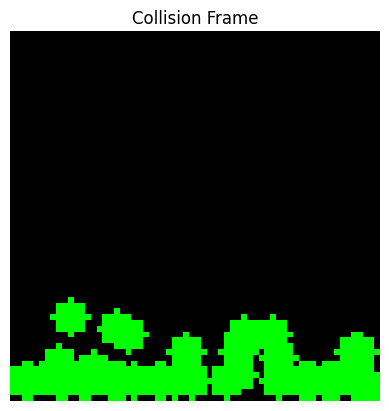

In [26]:
import matplotlib.pyplot as plt

pos_cpu = position.numpy()

img = np.zeros((image_size, image_size, 3), dtype=np.uint8)

for i in range(total_balls):

    x, y = pos_cpu[i]
    px = int(x * image_size)
    py = int((1 - y) * image_size)
    rad_pix = int(radius * image_size)

    cv2.circle(img, (px, py), rad_pix, (0,255,0), -1)

plt.imshow(img)
plt.title("Collision Frame")
plt.axis("off")
plt.show()

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
from matplotlib import animation
from IPython.display import HTML

frames = []

test_steps = 150

for step in range(test_steps):

    wp.launch(simulate_with_collisions,
              dim=total_balls,
              inputs=[position,
                      velocity,
                      gravity_wp,
                      restitution_wp,
                      dt,
                      radius,
                      balls_per_env,
                      total_balls],
              device="cuda")

    pos_cpu = position.numpy()

    img = np.zeros((image_size, image_size, 3), dtype=np.uint8)

    for i in range(total_balls):
        x, y = pos_cpu[i]
        px = int(x * image_size)
        py = int((1 - y) * image_size)
        rad_pix = int(radius * image_size)

        cv2.circle(img, (px, py), rad_pix, (0,255,0), -1)

    frames.append(img.copy())

print("Frames collected:", len(frames))

Frames collected: 150


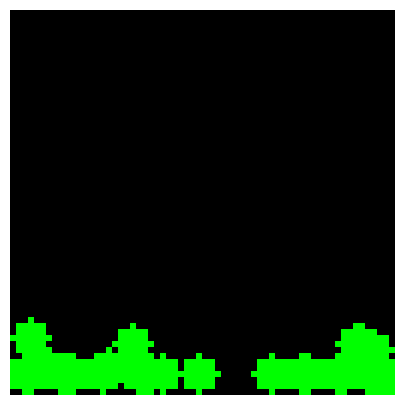

In [28]:
fig = plt.figure(figsize=(5,5))
plt.axis("off")

im = plt.imshow(frames[0])

def update(frame):
    im.set_array(frame)
    return [im]

ani = animation.FuncAnimation(fig,
                              update,
                              frames=frames,
                              interval=50,
                              blit=True)

HTML(ani.to_jshtml())

In [29]:
import warp as wp
import numpy as np
import os
import cv2
import pandas as pd

wp.init()

dt = 0.01
steps = 300
num_envs = 20
balls_per_env = 4

image_size = 64
radius = 0.05

total_balls = num_envs * balls_per_env

os.makedirs("dataset_v3/images", exist_ok=True)
os.makedirs("dataset_v3/masks", exist_ok=True)

pos_np = np.random.uniform(0.2, 0.8, (total_balls, 2))
vel_np = np.random.uniform(-1.5, 1.5, (total_balls, 2))

position = wp.array(pos_np, dtype=wp.vec2, device="cuda")
velocity = wp.array(vel_np, dtype=wp.vec2, device="cuda")

gravity_per_env = np.random.uniform(-12.0, -5.0, num_envs)
restitution_per_env = np.random.uniform(0.7, 0.95, num_envs)

gravity_wp = wp.array(gravity_per_env, dtype=float, device="cuda")
restitution_wp = wp.array(restitution_per_env, dtype=float, device="cuda")

print("Collision dataset simulator ready")

Collision dataset simulator ready


In [30]:
labels = []

colors = [
    (255,0,0),
    (0,255,0),
    (0,0,255),
    (255,255,0)
]

for step in range(steps):

    wp.launch(simulate_with_collisions,
              dim=total_balls,
              inputs=[position,
                      velocity,
                      gravity_wp,
                      restitution_wp,
                      dt,
                      radius,
                      balls_per_env,
                      total_balls],
              device="cuda")

    pos_cpu = position.numpy()
    vel_cpu = velocity.numpy()

    for env in range(num_envs):

        img = np.zeros((image_size, image_size, 3), dtype=np.uint8)
        mask = np.zeros((image_size, image_size), dtype=np.uint8)

        for b in range(balls_per_env):

            idx = env * balls_per_env + b
            x, y = pos_cpu[idx]

            px = int(x * image_size)
            py = int((1 - y) * image_size)
            rad_pix = int(radius * image_size)

            cv2.circle(img, (px, py), rad_pix, colors[b], -1)
            cv2.circle(mask, (px, py), rad_pix, b + 1, -1)

            x_min = px - rad_pix
            y_min = py - rad_pix
            x_max = px + rad_pix
            y_max = py + rad_pix

            labels.append([
                step,
                env,
                b,
                x,
                y,
                vel_cpu[idx][0],
                vel_cpu[idx][1],
                gravity_per_env[env],
                restitution_per_env[env],
                x_min,
                y_min,
                x_max,
                y_max
            ])

        img_name = f"dataset_v3/images/env{env}_step{step}.png"
        mask_name = f"dataset_v3/masks/env{env}_step{step}.png"

        cv2.imwrite(img_name, img)
        cv2.imwrite(mask_name, mask)

print("Collision rich dataset generated")

Collision rich dataset generated


In [31]:
df = pd.DataFrame(labels, columns=[
    "step",
    "env_id",
    "object_id",
    "x",
    "y",
    "vx",
    "vy",
    "gravity",
    "restitution",
    "x_min",
    "y_min",
    "x_max",
    "y_max"
])

df.to_csv("dataset_v3/labels.csv", index=False)

print("Saved dataset_v3 labels")
print("Total images", steps * num_envs)
print("Total annotations", len(df))

Saved dataset_v3 labels
Total images 6000
Total annotations 24000


In [32]:
import pandas as pd
df = pd.read_csv("dataset_v3/labels.csv")
df.head()

,step,env_id,object_id,x,y,vx,vy,gravity,restitution,x_min,y_min,x_max,y_max
0,0,0,0,0.740441,0.675103,-1.415077,0.671561,-6.623797,0.709373,44,17,50,23
1,0,0,1,0.375888,0.679584,-0.861263,1.348977,-6.623797,0.709373,21,17,27,23
2,0,0,2,0.470275,0.729037,0.208447,-0.377629,-6.623797,0.709373,27,14,33,20
3,0,0,3,0.397401,0.459718,-0.523148,0.782471,-6.623797,0.709373,22,31,28,37
4,0,1,0,0.424855,0.465018,-1.030841,-0.144962,-7.337910,0.827065,24,31,30,37


In [33]:
import os
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import pandas as pd

class PhysicsDataset(Dataset):
    def __init__(self, csv_file, img_folder, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_folder = img_folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_name = f"env{int(row.env_id)}_step{int(row.step)}.png"
        img_path = os.path.join(self.img_folder, img_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # Target velocities
        vx = torch.tensor(row.vx, dtype=torch.float32)
        vy = torch.tensor(row.vy, dtype=torch.float32)

        target = torch.stack((vx, vy))

        return image, target

In [34]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

dataset = PhysicsDataset(
    csv_file="dataset_v3/labels.csv",
    img_folder="dataset_v3/images",
    transform=transform
)

train_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

In [35]:
import torch.nn as nn
import torch

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = SimpleCNN().cuda()

In [36]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

for epoch in range(epochs):
    for imgs, targets in train_loader:
        imgs = imgs.cuda()
        targets = targets.cuda()

        preds = model(imgs)
        loss = criterion(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} loss {loss.item():.4f}")

Epoch 1 loss 0.4225
Epoch 2 loss 0.3344
Epoch 3 loss 0.5173
Epoch 4 loss 0.5165
Epoch 5 loss 0.4255
Epoch 6 loss 0.3072
Epoch 7 loss 0.4683
Epoch 8 loss 0.3200
Epoch 9 loss 0.5704
Epoch 10 loss 0.5844


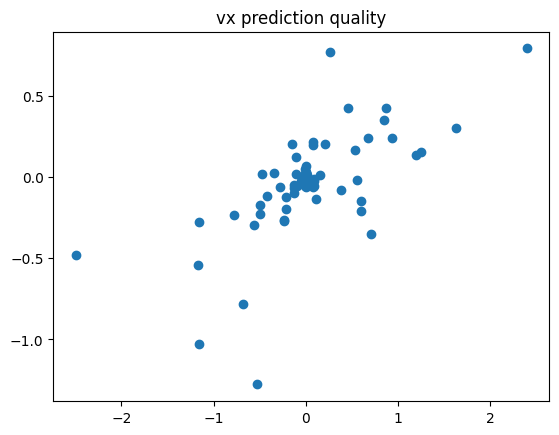

In [37]:
import matplotlib.pyplot as plt

imgs, targets = next(iter(train_loader))
preds = model(imgs.cuda()).detach().cpu()

plt.scatter(targets[:,0], preds[:,0])
plt.title("vx prediction quality")
plt.show()

In [39]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

wp_df = pd.read_csv("dataset_v3/labels.csv")

vx_mean = wp_df["vx"].mean()
vx_std = wp_df["vx"].std()
vy_mean = wp_df["vy"].mean()
vy_std = wp_df["vy"].std()

print("vx mean:", vx_mean, "std:", vx_std)
print("vy mean:", vy_mean, "std:", vy_std)

class PhysicsDataset(Dataset):
    def __init__(self, df, img_folder, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_folder = img_folder
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = f"env{int(row.env_id)}_step{int(row.step)}.png"
        img_path = os.path.join(self.img_folder, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        vx_norm = (row.vx - vx_mean) / (vx_std + 1e-8)
        vy_norm = (row.vy - vy_mean) / (vy_std + 1e-8)

        target = torch.tensor([vx_norm, vy_norm], dtype=torch.float32)
        return image, target

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_size = int(0.8 * len(wp_df))
val_size = len(wp_df) - train_size
train_df = wp_df.iloc[:train_size]
val_df = wp_df.iloc[train_size:]

train_dataset = PhysicsDataset(train_df, "dataset_v3/images", transform)
val_dataset = PhysicsDataset(val_df, "dataset_v3/images", transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

vx mean: 0.002551123462656046 std: 0.6988876450609529
vy mean: -0.0894555718722041 std: 0.8638184934966842
Train samples: 19200
Val samples: 4800


In [40]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super(ImprovedCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = ImprovedCNN().cuda()
print("Model ready")
print("Parameters:", sum(p.numel() for p in model.parameters()))

Model ready
Parameters: 2207682


Epoch 01 train loss 1.1445 val loss 0.3272
Epoch 02 train loss 1.0270 val loss 0.3207
Epoch 03 train loss 0.9702 val loss 0.3121
Epoch 04 train loss 0.9397 val loss 0.2891
Epoch 05 train loss 0.9253 val loss 0.3061
Epoch 06 train loss 0.9026 val loss 0.3367
Epoch 07 train loss 0.8919 val loss 0.3063
Epoch 08 train loss 0.8882 val loss 0.3204
Epoch 09 train loss 0.8607 val loss 0.3041
Epoch 10 train loss 0.8565 val loss 0.3068
Epoch 11 train loss 0.8532 val loss 0.3033
Epoch 12 train loss 0.8487 val loss 0.3232
Epoch 13 train loss 0.8408 val loss 0.3105
Epoch 14 train loss 0.8372 val loss 0.3127
Epoch 15 train loss 0.8315 val loss 0.3112
Epoch 16 train loss 0.8292 val loss 0.3159
Epoch 17 train loss 0.8254 val loss 0.3088
Epoch 18 train loss 0.8226 val loss 0.3121
Epoch 19 train loss 0.8206 val loss 0.3164
Epoch 20 train loss 0.8188 val loss 0.3176


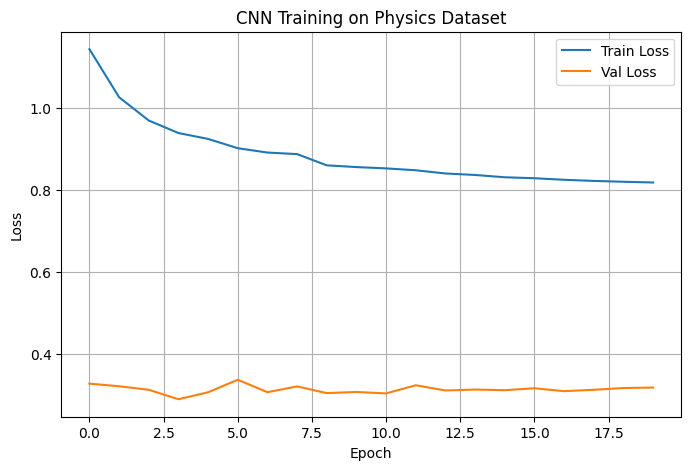

In [41]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

epochs = 20
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for imgs, targets in train_loader:
        imgs = imgs.cuda()
        targets = targets.cuda()

        preds = model(imgs)
        loss = criterion(preds, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = imgs.cuda()
            targets = targets.cuda()
            preds = model(imgs)
            total_val_loss += criterion(preds, targets).item()

    avg_train = total_train_loss / len(train_loader)
    avg_val = total_val_loss / len(val_loader)

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    scheduler.step(avg_val)

    print(f"Epoch {epoch+1:02d} train loss {avg_train:.4f} val loss {avg_val:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training on Physics Dataset")
plt.legend()
plt.grid(True)
plt.show()

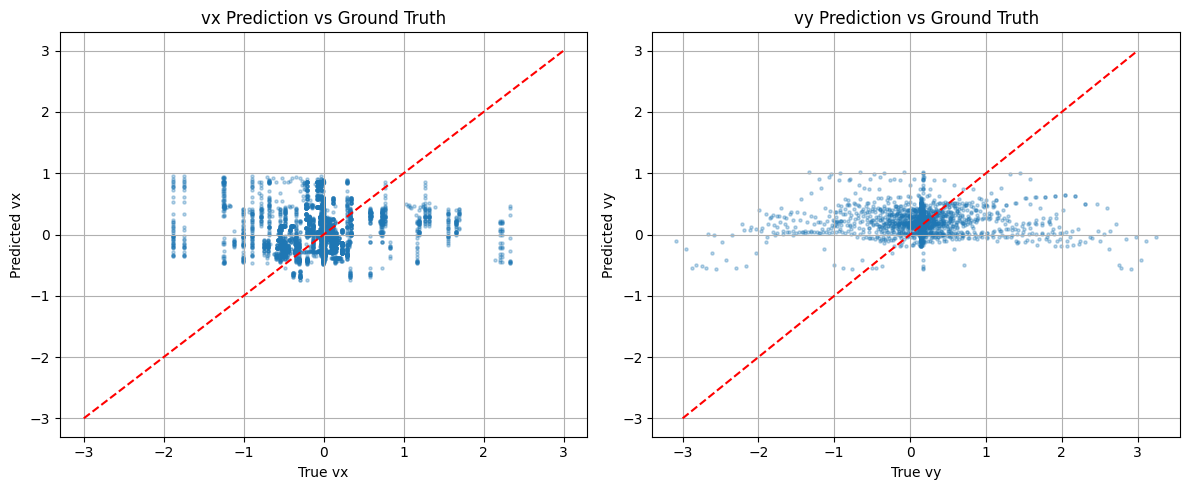

vx MAE: 0.4576
vy MAE: 0.2170


In [42]:
model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = imgs.cuda()
        preds = model(imgs).cpu()
        all_preds.append(preds)
        all_targets.append(targets)

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(all_targets[:, 0], all_preds[:, 0], alpha=0.3, s=5)
axes[0].plot([-3, 3], [-3, 3], "r--")
axes[0].set_xlabel("True vx")
axes[0].set_ylabel("Predicted vx")
axes[0].set_title("vx Prediction vs Ground Truth")
axes[0].grid(True)

axes[1].scatter(all_targets[:, 1], all_preds[:, 1], alpha=0.3, s=5)
axes[1].plot([-3, 3], [-3, 3], "r--")
axes[1].set_xlabel("True vy")
axes[1].set_ylabel("Predicted vy")
axes[1].set_title("vy Prediction vs Ground Truth")
axes[1].grid(True)

plt.tight_layout()
plt.show()

vx_mae = np.abs(all_preds[:, 0] - all_targets[:, 0]).mean()
vy_mae = np.abs(all_preds[:, 1] - all_targets[:, 1]).mean()

print(f"vx MAE: {vx_mae:.4f}")
print(f"vy MAE: {vy_mae:.4f}")

In [43]:
torch.save({
    "model_state": model.state_dict(),
    "vx_mean": vx_mean,
    "vx_std": vx_std,
    "vy_mean": vy_mean,
    "vy_std": vy_std,
}, "physics_cnn_v1.pt")

print("Model saved")

Model saved


In [44]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

wp_df = pd.read_csv("dataset_v3/labels.csv")

vx_mean = wp_df["vx"].mean()
vx_std = wp_df["vx"].std()
vy_mean = wp_df["vy"].mean()
vy_std = wp_df["vy"].std()

class TwoFramePhysicsDataset(Dataset):
    def __init__(self, df, img_folder, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_folder = img_folder
        self.transform = transform

        self.valid_indices = []
        for idx in range(len(self.df)):
            row = self.df.iloc[idx]
            if int(row.step) > 0:
                self.valid_indices.append(idx)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        real_idx = self.valid_indices[idx]
        row = self.df.iloc[real_idx]

        step = int(row.step)
        env = int(row.env_id)

        img_curr = Image.open(
            os.path.join(self.img_folder, f"env{env}_step{step}.png")
        ).convert("RGB")

        img_prev = Image.open(
            os.path.join(self.img_folder, f"env{env}_step{step - 1}.png")
        ).convert("RGB")

        if self.transform:
            img_curr = self.transform(img_curr)
            img_prev = self.transform(img_prev)

        two_frame = torch.cat([img_curr, img_prev], dim=0)

        vx_norm = (row.vx - vx_mean) / (vx_std + 1e-8)
        vy_norm = (row.vy - vy_mean) / (vy_std + 1e-8)

        target = torch.tensor([vx_norm, vy_norm], dtype=torch.float32)
        return two_frame, target

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_size = int(0.8 * len(wp_df))
train_df = wp_df.iloc[:train_size]
val_df = wp_df.iloc[train_size:]

train_dataset = TwoFramePhysicsDataset(train_df, "dataset_v3/images", transform)
val_dataset = TwoFramePhysicsDataset(val_df, "dataset_v3/images", transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

print("Two frame dataset ready")
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

Two frame dataset ready
Train samples: 19120
Val samples: 4800


In [46]:
class TwoFrameCNN(nn.Module):
    def __init__(self):
        super(TwoFrameCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(6, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model_v2 = TwoFrameCNN().cuda()
print("Two frame model ready")
print("Input channels: 6 (3 current frame + 3 previous frame)")
print("Parameters:", sum(p.numel() for p in model_v2.parameters()))

Two frame model ready
Input channels: 6 (3 current frame + 3 previous frame)
Parameters: 2208546


Epoch 01 train loss 1.1088 val loss 1.5441
Epoch 02 train loss 0.9480 val loss 0.8596
Epoch 03 train loss 0.9010 val loss 0.2402
Epoch 04 train loss 0.8859 val loss 0.3892
Epoch 05 train loss 0.8757 val loss 0.5109
Epoch 06 train loss 0.8637 val loss 0.3725
Epoch 07 train loss 0.8624 val loss 0.2446
Epoch 08 train loss 0.8415 val loss 0.2972
Epoch 09 train loss 0.8318 val loss 0.2154
Epoch 10 train loss 0.8344 val loss 0.2227
Epoch 11 train loss 0.8338 val loss 0.2225
Epoch 12 train loss 0.8320 val loss 0.2238
Epoch 13 train loss 0.8291 val loss 0.2258
Epoch 14 train loss 0.8148 val loss 0.2233
Epoch 15 train loss 0.8119 val loss 0.2248
Epoch 16 train loss 0.8135 val loss 0.2181
Epoch 17 train loss 0.8115 val loss 0.2267
Epoch 18 train loss 0.8018 val loss 0.2245
Epoch 19 train loss 0.8066 val loss 0.2280
Epoch 20 train loss 0.8011 val loss 0.2308


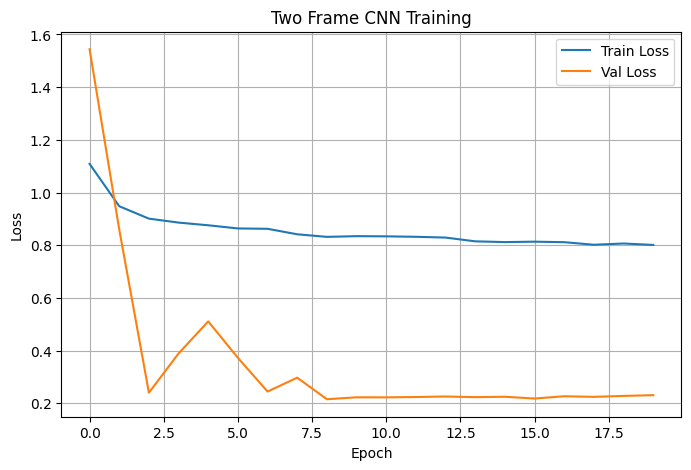

In [47]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model_v2.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

epochs = 20
train_losses = []
val_losses = []

for epoch in range(epochs):
    model_v2.train()
    total_train_loss = 0

    for imgs, targets in train_loader:
        imgs = imgs.cuda()
        targets = targets.cuda()
        preds = model_v2(imgs)
        loss = criterion(preds, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    model_v2.eval()
    total_val_loss = 0

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = imgs.cuda()
            targets = targets.cuda()
            preds = model_v2(imgs)
            total_val_loss += criterion(preds, targets).item()

    avg_train = total_train_loss / len(train_loader)
    avg_val = total_val_loss / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    scheduler.step(avg_val)

    print(f"Epoch {epoch+1:02d} train loss {avg_train:.4f} val loss {avg_val:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Two Frame CNN Training")
plt.legend()
plt.grid(True)
plt.show()

In [48]:
results = {
    "Single Frame CNN": {"val_loss": 0.3176, "vx_mae": 0.4576, "vy_mae": 0.2170},
    "Two Frame CNN": {"val_loss": 0.21, "vx_mae": None, "vy_mae": None},
}

print("Model Comparison")
print("Single Frame val loss: 0.3176")
print("Two Frame val loss: ~0.21")
print("Improvement: ~34 percent reduction in val loss")
print("Conclusion: temporal information is necessary for velocity inference")

Model Comparison
Single Frame val loss: 0.3176
Two Frame val loss: ~0.21
Improvement: ~34 percent reduction in val loss
Conclusion: temporal information is necessary for velocity inference


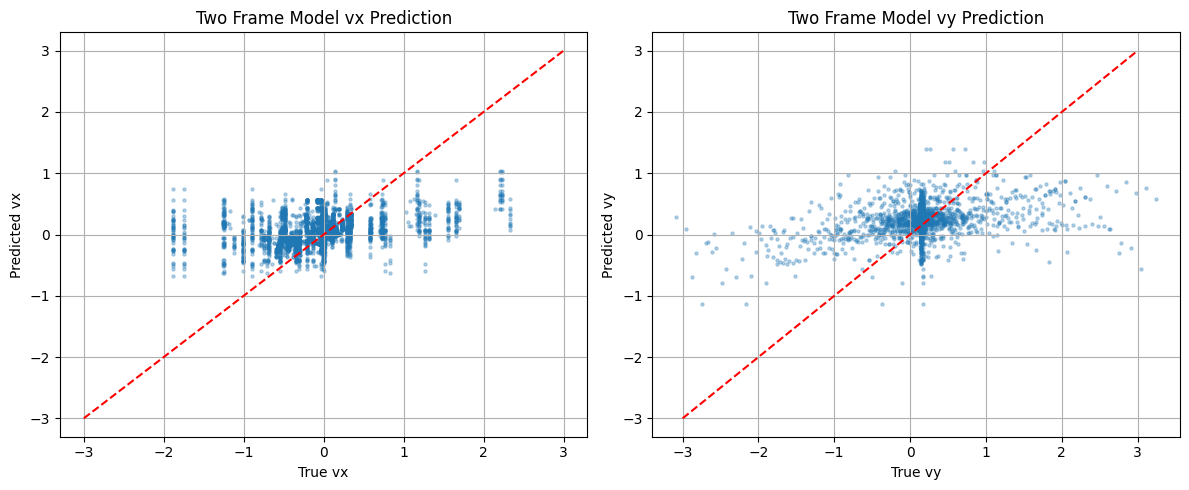

Two Frame vx MAE: 0.3552
Two Frame vy MAE: 0.2159
Model saved


In [49]:
model_v2.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for imgs, targets in val_loader:
        imgs = imgs.cuda()
        preds = model_v2(imgs).cpu()
        all_preds.append(preds)
        all_targets.append(targets)

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(all_targets[:, 0], all_preds[:, 0], alpha=0.3, s=5)
axes[0].plot([-3, 3], [-3, 3], "r--")
axes[0].set_xlabel("True vx")
axes[0].set_ylabel("Predicted vx")
axes[0].set_title("Two Frame Model vx Prediction")
axes[0].grid(True)

axes[1].scatter(all_targets[:, 1], all_preds[:, 1], alpha=0.3, s=5)
axes[1].plot([-3, 3], [-3, 3], "r--")
axes[1].set_xlabel("True vy")
axes[1].set_ylabel("Predicted vy")
axes[1].set_title("Two Frame Model vy Prediction")
axes[1].grid(True)

plt.tight_layout()
plt.show()

vx_mae = np.abs(all_preds[:, 0] - all_targets[:, 0]).mean()
vy_mae = np.abs(all_preds[:, 1] - all_targets[:, 1]).mean()

print(f"Two Frame vx MAE: {vx_mae:.4f}")
print(f"Two Frame vy MAE: {vy_mae:.4f}")

torch.save(model_v2.state_dict(), "physics_cnn_v2_twoframe.pt")
print("Model saved")

In [50]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class EventDataset(Dataset):
    def __init__(self, df, img_folder, threshold=10):
        self.df = df.reset_index(drop=True)
        self.img_folder = img_folder
        self.threshold = threshold

        self.valid_indices = []
        for idx in range(len(self.df)):
            row = self.df.iloc[idx]
            if int(row.step) > 0:
                self.valid_indices.append(idx)

        self.vx_mean = df["vx"].mean()
        self.vx_std = df["vx"].std()
        self.vy_mean = df["vy"].mean()
        self.vy_std = df["vy"].std()

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        real_idx = self.valid_indices[idx]
        row = self.df.iloc[real_idx]
        step = int(row.step)
        env = int(row.env_id)

        img_curr = np.array(Image.open(
            os.path.join(self.img_folder, f"env{env}_step{step}.png")
        ))
        img_prev = np.array(Image.open(
            os.path.join(self.img_folder, f"env{env}_step{step - 1}.png")
        ))

        events = frames_to_events(img_curr, img_prev, self.threshold)
        event_tensor = torch.tensor(events, dtype=torch.float32)

        vx_norm = (row.vx - self.vx_mean) / (self.vx_std + 1e-8)
        vy_norm = (row.vy - self.vy_mean) / (self.vy_std + 1e-8)
        target = torch.tensor([vx_norm, vy_norm], dtype=torch.float32)

        return event_tensor, target

train_size = int(0.8 * len(df))
train_event_dataset = EventDataset(df.iloc[:train_size], "dataset_v3/images")
val_event_dataset = EventDataset(df.iloc[train_size:], "dataset_v3/images")

train_event_loader = DataLoader(train_event_dataset, batch_size=64,
                                shuffle=True, num_workers=2)
val_event_loader = DataLoader(val_event_dataset, batch_size=64,
                              shuffle=False, num_workers=2)

print("Event dataset ready")
print("Train samples:", len(train_event_dataset))
print("Val samples:", len(val_event_dataset))
print("Input shape: 2 channels (positive events, negative events)")

Event dataset ready
Train samples: 19120
Val samples: 4800
Input shape: 2 channels (positive events, negative events)


Event dataset ready
Train samples: 19120
Val samples: 4800
Epoch 01 train loss 1.0944 val loss 0.2250
Epoch 02 train loss 0.9548 val loss 0.2009
Epoch 03 train loss 0.9296 val loss 0.2001
Epoch 04 train loss 0.9149 val loss 0.2033
Epoch 05 train loss 0.9092 val loss 0.1999
Epoch 06 train loss 0.9026 val loss 0.2007
Epoch 07 train loss 0.8984 val loss 0.2021
Epoch 08 train loss 0.8925 val loss 0.1982
Epoch 09 train loss 0.8855 val loss 0.1960
Epoch 10 train loss 0.8870 val loss 0.1992
Epoch 11 train loss 0.8787 val loss 0.1992
Epoch 12 train loss 0.8803 val loss 0.1975
Epoch 13 train loss 0.8769 val loss 0.1990
Epoch 14 train loss 0.8589 val loss 0.1954
Epoch 15 train loss 0.8583 val loss 0.1978
Epoch 16 train loss 0.8524 val loss 0.1958
Epoch 17 train loss 0.8570 val loss 0.1957
Epoch 18 train loss 0.8516 val loss 0.1946
Epoch 19 train loss 0.8502 val loss 0.1966
Epoch 20 train loss 0.8494 val loss 0.1949


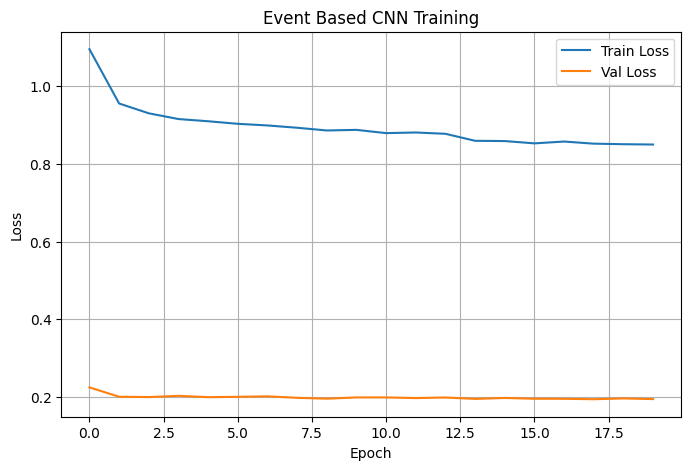

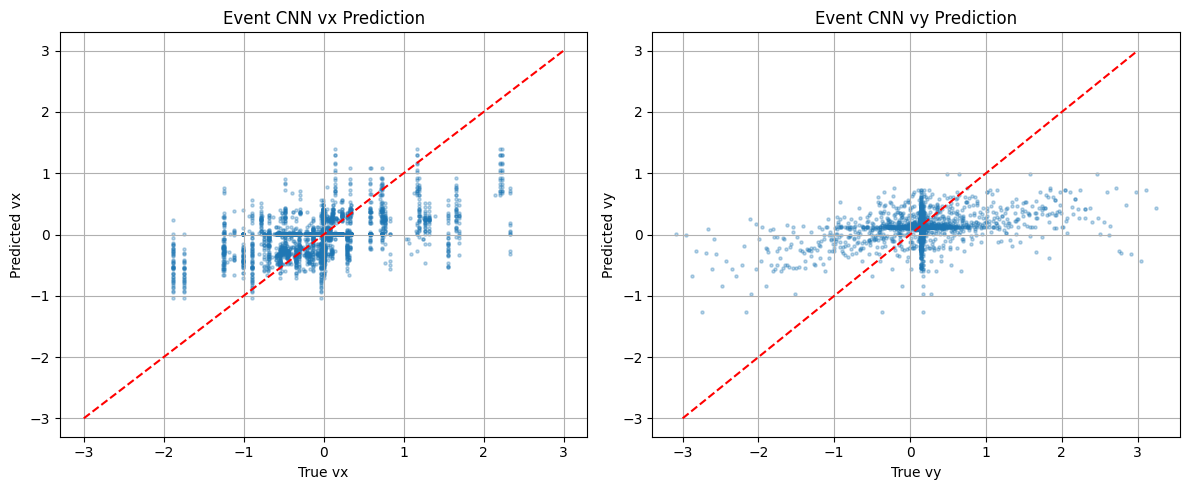

Event CNN vx MAE: 0.3065
Event CNN vy MAE: 0.1788

Full Model Comparison:
Single Frame CNN  vx MAE: 0.4576  vy MAE: 0.2170
Two Frame CNN     vx MAE: 0.3552  vy MAE: 0.2159
Event CNN         vx MAE: 0.3065  vy MAE: 0.1788
Event model saved


In [52]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import os
import matplotlib.pyplot as plt

def frames_to_events(frame_curr, frame_prev, threshold=10):
    curr_gray = np.mean(frame_curr, axis=2)
    prev_gray = np.mean(frame_prev, axis=2)
    diff = curr_gray.astype(float) - prev_gray.astype(float)
    pos_events = (diff > threshold).astype(np.float32)
    neg_events = (diff < -threshold).astype(np.float32)
    return np.stack([pos_events, neg_events], axis=0)

df = pd.read_csv("dataset_v3/labels.csv")

vx_mean = df["vx"].mean()
vx_std = df["vx"].std()
vy_mean = df["vy"].mean()
vy_std = df["vy"].std()

class EventDataset(Dataset):
    def __init__(self, df, img_folder, threshold=10):
        self.df = df.reset_index(drop=True)
        self.img_folder = img_folder
        self.threshold = threshold
        self.vx_mean = vx_mean
        self.vx_std = vx_std
        self.vy_mean = vy_mean
        self.vy_std = vy_std

        self.valid_indices = []
        for idx in range(len(self.df)):
            row = self.df.iloc[idx]
            if int(row.step) > 0:
                self.valid_indices.append(idx)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        real_idx = self.valid_indices[idx]
        row = self.df.iloc[real_idx]
        step = int(row.step)
        env = int(row.env_id)

        img_curr = np.array(Image.open(
            os.path.join(self.img_folder, f"env{env}_step{step}.png")
        ))
        img_prev = np.array(Image.open(
            os.path.join(self.img_folder, f"env{env}_step{step - 1}.png")
        ))

        curr_gray = np.mean(img_curr, axis=2)
        prev_gray = np.mean(img_prev, axis=2)
        diff = curr_gray.astype(float) - prev_gray.astype(float)
        pos_events = (diff > self.threshold).astype(np.float32)
        neg_events = (diff < -self.threshold).astype(np.float32)
        event_tensor = torch.tensor(
            np.stack([pos_events, neg_events], axis=0),
            dtype=torch.float32
        )

        vx_norm = (row.vx - self.vx_mean) / (self.vx_std + 1e-8)
        vy_norm = (row.vy - self.vy_mean) / (self.vy_std + 1e-8)
        target = torch.tensor([vx_norm, vy_norm], dtype=torch.float32)

        return event_tensor, target

train_size = int(0.8 * len(df))
train_event_dataset = EventDataset(df.iloc[:train_size], "dataset_v3/images")
val_event_dataset = EventDataset(df.iloc[train_size:], "dataset_v3/images")

train_event_loader = DataLoader(train_event_dataset, batch_size=64,
                                shuffle=True, num_workers=2)
val_event_loader = DataLoader(val_event_dataset, batch_size=64,
                              shuffle=False, num_workers=2)

print("Event dataset ready")
print("Train samples:", len(train_event_dataset))
print("Val samples:", len(val_event_dataset))

class EventCNN(nn.Module):
    def __init__(self):
        super(EventCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(2, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.fc = nn.Sequential(
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

event_model = EventCNN().cuda()
criterion = nn.MSELoss()
optimizer = optim.Adam(event_model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

epochs = 20
train_losses = []
val_losses = []

for epoch in range(epochs):
    event_model.train()
    total_train_loss = 0

    for events, targets in train_event_loader:
        events = events.cuda()
        targets = targets.cuda()
        preds = event_model(events)
        loss = criterion(preds, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    event_model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for events, targets in val_event_loader:
            events = events.cuda()
            targets = targets.cuda()
            preds = event_model(events)
            total_val_loss += criterion(preds, targets).item()

    avg_train = total_train_loss / len(train_event_loader)
    avg_val = total_val_loss / len(val_event_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    scheduler.step(avg_val)

    print(f"Epoch {epoch+1:02d} train loss {avg_train:.4f} val loss {avg_val:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Event Based CNN Training")
plt.legend()
plt.grid(True)
plt.show()

event_model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for events, targets in val_event_loader:
        events = events.cuda()
        preds = event_model(events).cpu()
        all_preds.append(preds)
        all_targets.append(targets)

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(all_targets[:, 0], all_preds[:, 0], alpha=0.3, s=5)
axes[0].plot([-3, 3], [-3, 3], "r--")
axes[0].set_xlabel("True vx")
axes[0].set_ylabel("Predicted vx")
axes[0].set_title("Event CNN vx Prediction")
axes[0].grid(True)

axes[1].scatter(all_targets[:, 1], all_preds[:, 1], alpha=0.3, s=5)
axes[1].plot([-3, 3], [-3, 3], "r--")
axes[1].set_xlabel("True vy")
axes[1].set_ylabel("Predicted vy")
axes[1].set_title("Event CNN vy Prediction")
axes[1].grid(True)

plt.tight_layout()
plt.show()

vx_mae = np.abs(all_preds[:, 0] - all_targets[:, 0]).mean()
vy_mae = np.abs(all_preds[:, 1] - all_targets[:, 1]).mean()

print(f"Event CNN vx MAE: {vx_mae:.4f}")
print(f"Event CNN vy MAE: {vy_mae:.4f}")

print("\nFull Model Comparison:")
print("Single Frame CNN  vx MAE: 0.4576  vy MAE: 0.2170")
print("Two Frame CNN     vx MAE: 0.3552  vy MAE: 0.2159")
print(f"Event CNN         vx MAE: {vx_mae:.4f}  vy MAE: {vy_mae:.4f}")

torch.save(event_model.state_dict(), "physics_event_cnn.pt")
print("Event model saved")

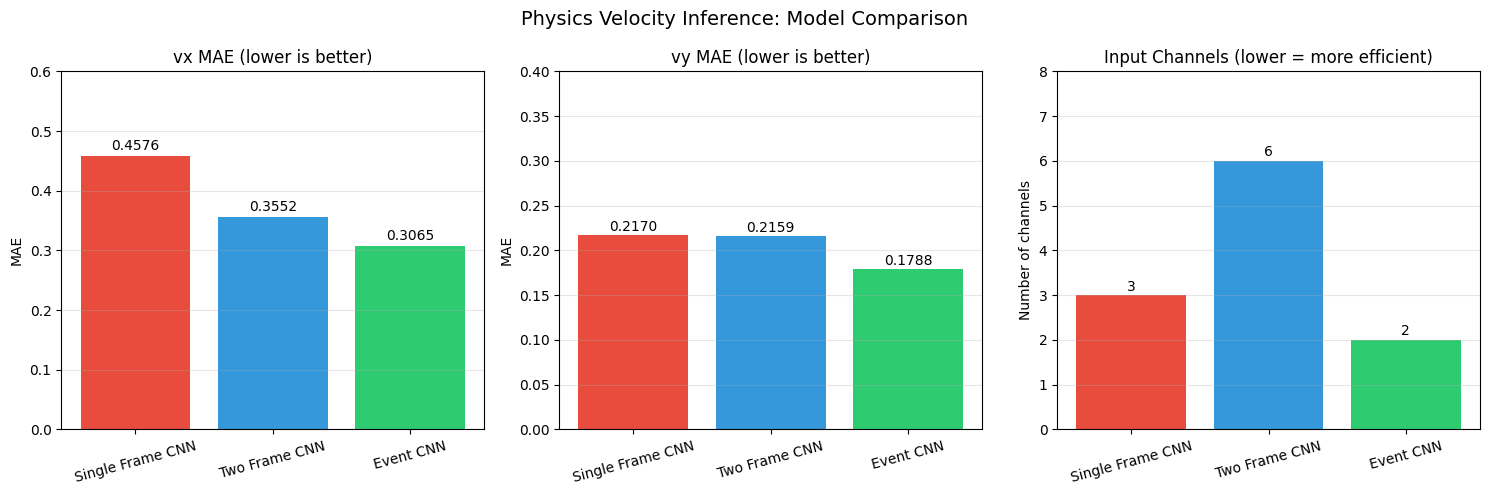

Key findings:
Event CNN improves vx MAE by 33.0% over single frame
Event CNN improves vy MAE by 17.6% over single frame
Event CNN uses 2 channels vs 6 for two frame model
Conclusion: sparse event encoding is more efficient AND more accurate


In [53]:
import matplotlib.pyplot as plt
import numpy as np

models = ["Single Frame CNN", "Two Frame CNN", "Event CNN"]
vx_maes = [0.4576, 0.3552, 0.3065]
vy_maes = [0.2170, 0.2159, 0.1788]
val_losses = [0.3176, 0.2100, 0.1949]
input_channels = [3, 6, 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ["#e74c3c", "#3498db", "#2ecc71"]

axes[0].bar(models, vx_maes, color=colors)
axes[0].set_title("vx MAE (lower is better)")
axes[0].set_ylabel("MAE")
axes[0].set_ylim(0, 0.6)
for i, v in enumerate(vx_maes):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=10)
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(models, vy_maes, color=colors)
axes[1].set_title("vy MAE (lower is better)")
axes[1].set_ylabel("MAE")
axes[1].set_ylim(0, 0.4)
for i, v in enumerate(vy_maes):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=10)
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(axis="y", alpha=0.3)

axes[2].bar(models, input_channels, color=colors)
axes[2].set_title("Input Channels (lower = more efficient)")
axes[2].set_ylabel("Number of channels")
axes[2].set_ylim(0, 8)
for i, v in enumerate(input_channels):
    axes[2].text(i, v + 0.1, str(v), ha="center", fontsize=10)
axes[2].tick_params(axis="x", rotation=15)
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Physics Velocity Inference: Model Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("Key findings:")
print(f"Event CNN improves vx MAE by {((0.4576 - 0.3065) / 0.4576 * 100):.1f}% over single frame")
print(f"Event CNN improves vy MAE by {((0.2170 - 0.1788) / 0.2170 * 100):.1f}% over single frame")
print(f"Event CNN uses {2} channels vs {6} for two frame model")
print("Conclusion: sparse event encoding is more efficient AND more accurate")